# Economics 5040: Dynamic Stochastic Modeling
## The McCall Search Model
### Lifetime job offers from \$70,000 to \$250,000

This notebook is a dollar version of the McCall job-search model in Sargent and Stachurski, *Intermediate Quantitative Economics with Python*, “Job Search I: The McCall Search Model.”

In that lecture the wage grid runs from 10 to 60 in abstract units, and a period is a month. Here a period is a year, and every offer is a **lifetime contract**: accept it and that annual salary is paid every year, forever. Offers lie between **\$70,000** and **\$250,000**. There is no quitting and no firing. (Separation is the subject of their next lecture.)


## 1. The decision

An unemployed worker draws one offer per year from a known distribution. The offer in hand is an annual salary \(w\).

- **Accept.** Receive \(w\) this year and every year after. The lifetime present value is
  \[
  \frac{w}{1-\beta}.
  \]
- **Reject.** Receive unemployment income \(c\) this year (benefits plus the value of time) and draw a fresh offer next year.

The worker maximizes expected discounted lifetime income. The discount factor \(\beta\in(0,1)\) is annual.

The Bellman equation is

\[
v(w)=\max\left\{\frac{w}{1-\beta},\; c+\beta\sum_{w'}v(w')\,q(w')\right\}.
\]

The second argument does not depend on the current offer. So there is a single cutoff, the **reservation salary** \(\bar w\): accept if \(w\ge\bar w\) and keep searching otherwise. At the cutoff the worker is indifferent,

\[
\frac{\bar w}{1-\beta}=c+\beta\sum_{w'}v(w')\,q(w'),
\]
which rearranges to

\[
\bar w=(1-\beta)\left(c+\beta\sum_{w'}v(w')\,q(w')\right).
\]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import betabinom

plt.rcParams.update({
    "figure.figsize": (8, 4.6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
})

def dollar_axis(ax, axis="x"):
    fmt = FuncFormatter(lambda x, pos: f"${x/1000:.0f}k")
    if axis == "x":
        ax.xaxis.set_major_formatter(fmt)
    else:
        ax.yaxis.set_major_formatter(fmt)

def million_axis(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1e6:.1f}m"))


## 2. The offer distribution

Salaries sit on 51 equally spaced points from \$70,000 to \$250,000. Probabilities come from a beta-binomial distribution with parameters \(n=50\), \(a=2\), \(b=5\).

That choice puts more probability on the lower part of the range: a draw near \$100,000 is much more common than a draw near \$220,000. The QuantEcon defaults (\(a=200\), \(b=100\)) are much tighter, so almost every offer would sit near \$190,000 and the endpoints of this grid would barely matter.

Baseline parameters:

- discount factor \(\beta=0.95\) (a 5 percent annual discount rate)
- unemployment income \(c=\$30{,}000\), which is **below every job offer**


In [2]:
# Grid and distribution
N = 50
A, B = 2.0, 5.0
W_MIN, W_MAX = 70_000.0, 250_000.0

k = np.arange(N + 1)
q = betabinom.pmf(k, N, A, B)
q = q / q.sum()
w = np.linspace(W_MIN, W_MAX, N + 1)

# Preferences and unemployment income
BETA = 0.95
C = 30_000.0

mean_offer = float(w @ q)
cdf = np.cumsum(q)

def quantile(p):
    return float(w[np.searchsorted(cdf, p)])

print(f"Offers: ${W_MIN:,.0f} to ${W_MAX:,.0f}  ({N + 1} points)")
print(f"Mean offer:     ${mean_offer:,.0f}")
print(f"10th percentile: ${quantile(0.10):,.0f}")
print(f"Median offer:    ${quantile(0.50):,.0f}")
print(f"90th percentile: ${quantile(0.90):,.0f}")
print(f"beta = {BETA},  unemployment income c = ${C:,.0f}")


Offers: $70,000 to $250,000  (51 points)
Mean offer:     $121,429
10th percentile: $84,400
Median offer:    $116,800
90th percentile: $163,600
beta = 0.95,  unemployment income c = $30,000


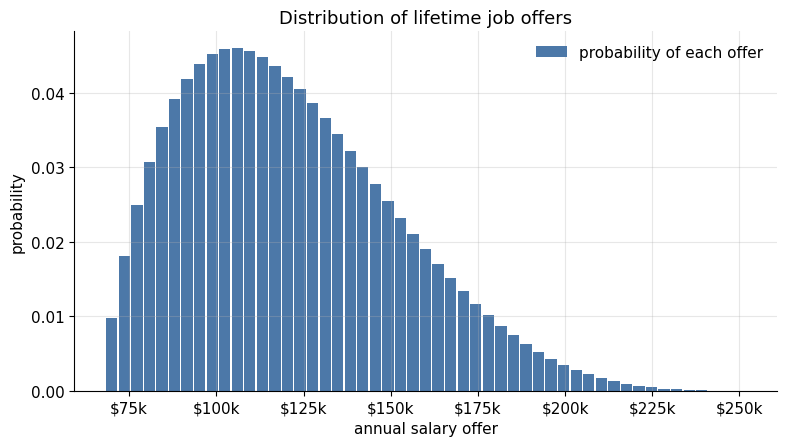

In [3]:
fig, ax = plt.subplots()
ax.bar(w, q, width=(W_MAX - W_MIN) / N * 0.9, color="#4C78A8", label="probability of each offer")
ax.set_xlabel("annual salary offer")
ax.set_ylabel("probability")
ax.set_title("Distribution of lifetime job offers")
dollar_axis(ax)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 3. Value-function iteration

Start from the value of accepting every offer, \(v_0(w)=w/(1-\beta)\), and apply the Bellman operator

\[
(Tv)(w)=\max\left\{\frac{w}{1-\beta},\; c+\beta\sum_{w'}v(w')\,q(w')\right\}.
\]

The unique fixed point is \(v\). Once it is known, the reservation salary is the wage that equates the two options inside the max.


In [4]:
def bellman(v, w, q, c, beta):
    """One application of the McCall Bellman operator."""
    lifetime_value = w / (1.0 - beta)          # accept: this salary forever
    keep_searching = c + beta * (v @ q)        # reject: c today, new offer tomorrow
    return np.maximum(lifetime_value, keep_searching)


def solve_mccall(w, q, c, beta, tol=1e-10, max_iter=10_000, return_path=False):
    """Iterate Tv to convergence and return v, the reservation salary, and diagnostics."""
    v = w / (1.0 - beta)
    path = [v.copy()] if return_path else None
    for iteration in range(1, max_iter + 1):
        v_next = bellman(v, w, q, c, beta)
        error = float(np.max(np.abs(v_next - v)))
        v = v_next
        if return_path and iteration <= 6:
            path.append(v.copy())
        if error < tol:
            break
    else:
        raise RuntimeError(f"value iteration did not converge in {max_iter} steps")

    continuation = c + beta * float(v @ q)
    reservation = (1.0 - beta) * continuation
    if return_path:
        return v, reservation, iteration, error, path
    return v, reservation, iteration, error


v, reservation, iters, error, path = solve_mccall(
    w, q, C, BETA, return_path=True
)

print(f"Converged in {iters} iterations  (sup-norm error {error:.2e})")
print(f"Reservation salary:  ${reservation:,.0f}")
print(f"Mean offer:          ${mean_offer:,.0f}")
print(f"Lifetime value of the reservation job: ${reservation / (1 - BETA):,.0f}")


Converged in 99 iterations  (sup-norm error 0.00e+00)
Reservation salary:  $140,579
Mean offer:          $121,429
Lifetime value of the reservation job: $2,811,580


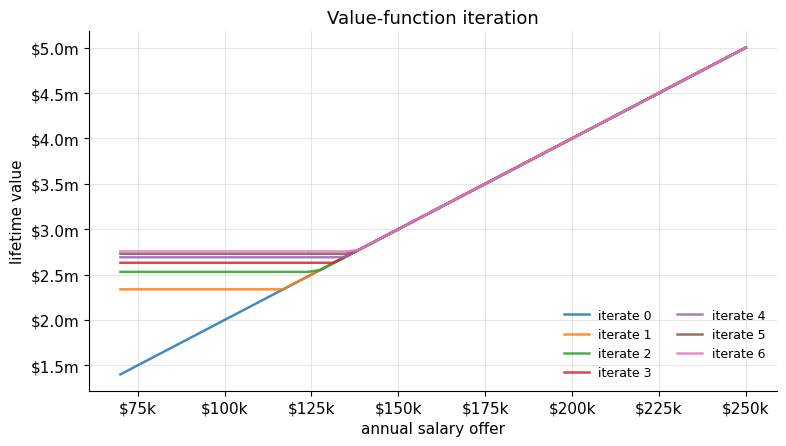

In [5]:
fig, ax = plt.subplots()
for i, v_i in enumerate(path):
    ax.plot(w, v_i, lw=1.8, alpha=0.85, label=f"iterate {i}")
ax.set_xlabel("annual salary offer")
ax.set_ylabel("lifetime value")
ax.set_title("Value-function iteration")
dollar_axis(ax)
million_axis(ax)
ax.legend(loc="lower right", frameon=False, fontsize=9, ncol=2)
fig.tight_layout()
plt.show()


## 4. The reservation salary

The flat part of the converged value function is the value of rejecting. The upward-sloping part is the lifetime value of accepting. They meet at \(\bar w\).

Because \(c\) is below every offer, a worker who had to decide myopically — comparing this year’s \(w\) with this year’s \(c\) — would take the first job. The optimal worker does not. A low offer is worth less, over a whole lifetime, than waiting for a better permanent salary.


In [6]:
accept = w >= reservation
p_accept = float(q[accept].sum())
p_reject_despite_beating_c = float(q[(w > C) & (w < reservation)].sum())
expected_years = 1.0 / p_accept  # offers until the first acceptance, including that offer

print(f"Reservation salary w_bar = ${reservation:,.0f}")
print(f"Probability an offer is accepted: {p_accept:.1%}")
print(f"Expected years until a job is accepted: {expected_years:.2f}")
print(f"Share of offers that beat c but are still rejected: {p_reject_despite_beating_c:.1%}")
print()
print(f"{'annual salary':>16} {'lifetime value':>16} {'decision':>12}")
for salary in [70_000, 90_000, 110_000, 130_000, 150_000, 180_000, 220_000, 250_000]:
    lifetime = salary / (1.0 - BETA)
    decision = "accept" if salary >= reservation else "keep looking"
    print(f"{salary:16,.0f} {lifetime:16,.0f} {decision:>12}")


Reservation salary w_bar = $140,579
Probability an offer is accepted: 26.0%
Expected years until a job is accepted: 3.85
Share of offers that beat c but are still rejected: 74.0%

   annual salary   lifetime value     decision
          70,000        1,400,000 keep looking
          90,000        1,800,000 keep looking
         110,000        2,200,000 keep looking
         130,000        2,600,000 keep looking
         150,000        3,000,000       accept
         180,000        3,600,000       accept
         220,000        4,400,000       accept
         250,000        5,000,000       accept


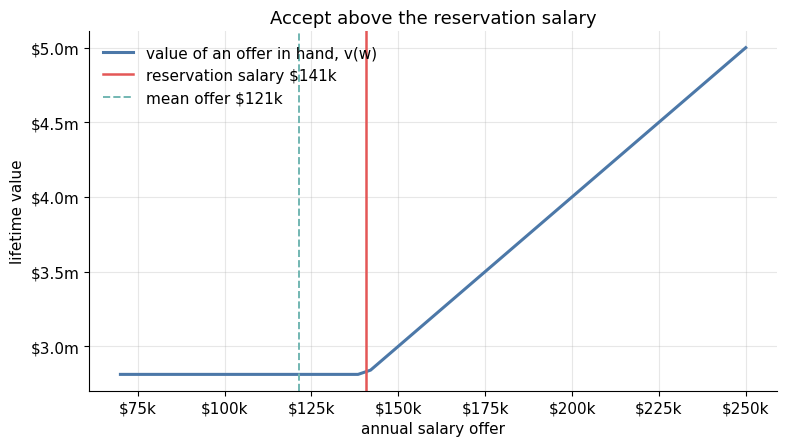

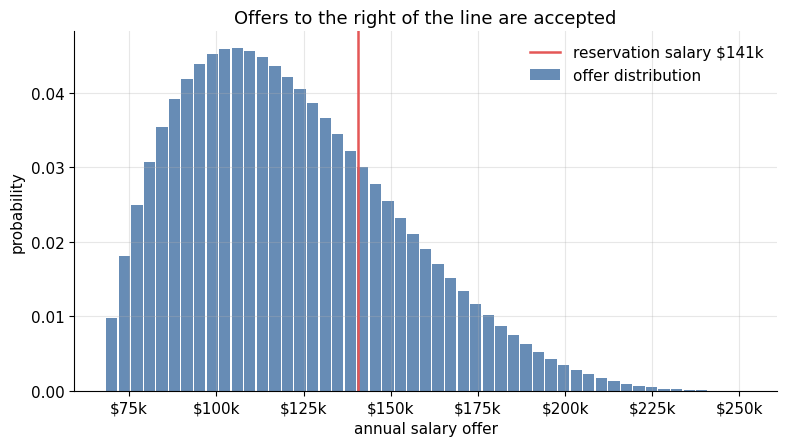

In [7]:
fig, ax = plt.subplots()
ax.plot(w, v, color="#4C78A8", lw=2.2, label="value of an offer in hand, v(w)")
ax.axvline(reservation, color="#E45756", lw=1.8, label=f"reservation salary ${reservation/1000:.0f}k")
ax.axvline(mean_offer, color="#72B7B2", lw=1.4, ls="--", label=f"mean offer ${mean_offer/1000:.0f}k")
ax.set_xlabel("annual salary offer")
ax.set_ylabel("lifetime value")
ax.set_title("Accept above the reservation salary")
dollar_axis(ax)
million_axis(ax)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.bar(w, q, width=(W_MAX - W_MIN) / N * 0.9, color="#4C78A8", alpha=0.85, label="offer distribution")
ax.axvline(reservation, color="#E45756", lw=1.8, label=f"reservation salary ${reservation/1000:.0f}k")
ax.set_xlabel("annual salary offer")
ax.set_ylabel("probability")
ax.set_title("Offers to the right of the line are accepted")
dollar_axis(ax)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5. What moves the reservation salary

Two comparative statics from the lecture, restated in dollars.

- A **more patient** worker (higher \(\beta\)) waits for a better lifetime contract, so \(\bar w\) rises.
- A **higher unemployment income** \(c\) makes waiting less painful, so \(\bar w\) rises and unemployment lasts longer.

The second result is the one that matters for unemployment insurance: more generous benefits raise the reservation salary and stretch the search.


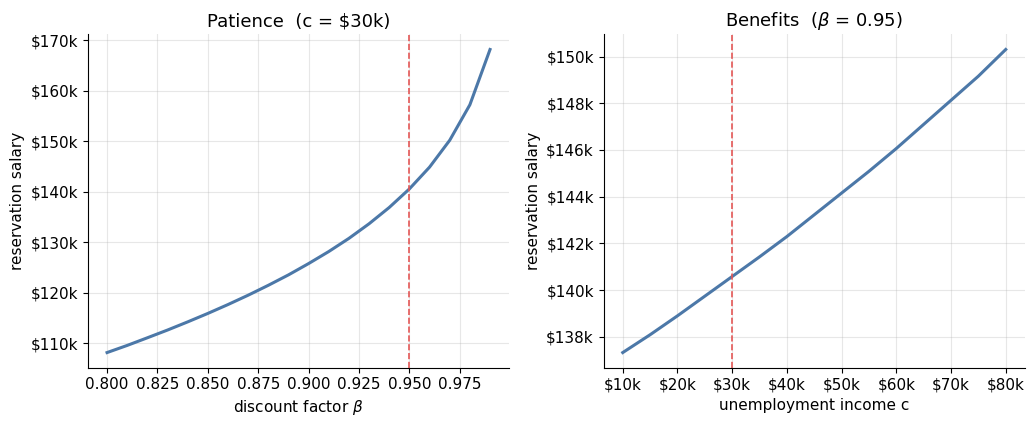

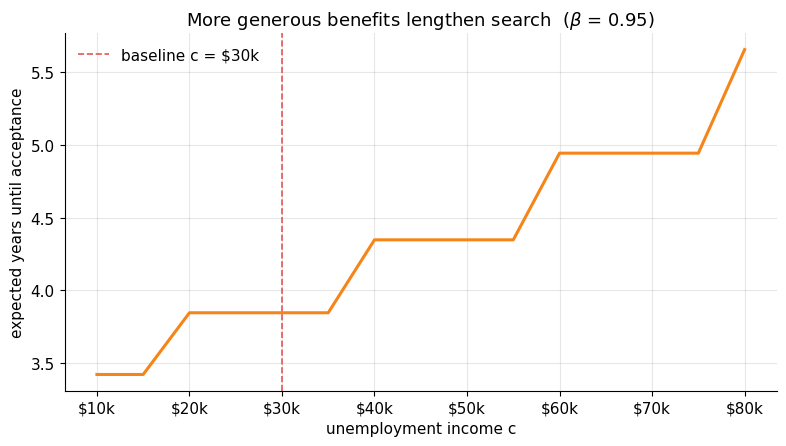

In [8]:
def reservation_salary(c, beta):
    _, w_bar, _, _ = solve_mccall(w, q, c, beta)
    return w_bar


beta_grid = np.linspace(0.80, 0.99, 20)
wbar_beta = np.array([reservation_salary(C, beta) for beta in beta_grid])

c_grid = np.linspace(10_000, 80_000, 15)
wbar_c = np.array([reservation_salary(c, BETA) for c in c_grid])
duration_c = np.array([1.0 / float(q[w >= wb].sum()) for wb in wbar_c])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

axes[0].plot(beta_grid, wbar_beta, color="#4C78A8", lw=2.2)
axes[0].axvline(BETA, color="#E45756", lw=1.2, ls="--")
axes[0].set_xlabel(r"discount factor $\beta$")
axes[0].set_ylabel("reservation salary")
axes[0].set_title(f"Patience  (c = ${C/1000:.0f}k)")
dollar_axis(axes[0], axis="y")

axes[1].plot(c_grid, wbar_c, color="#4C78A8", lw=2.2)
axes[1].axvline(C, color="#E45756", lw=1.2, ls="--")
axes[1].set_xlabel("unemployment income c")
axes[1].set_ylabel("reservation salary")
axes[1].set_title(rf"Benefits  ($\beta$ = {BETA})")
dollar_axis(axes[1], axis="x")
dollar_axis(axes[1], axis="y")

fig.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(c_grid, duration_c, color="#F58518", lw=2.2)
ax.axvline(C, color="#E45756", lw=1.2, ls="--", label=f"baseline c = ${C/1000:.0f}k")
ax.set_xlabel("unemployment income c")
ax.set_ylabel("expected years until acceptance")
ax.set_title(rf"More generous benefits lengthen search  ($\beta$ = {BETA})")
dollar_axis(ax, axis="x")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 6. Simulated careers

Draw a salary each year until it clears the reservation salary. If the accepted salary arrives in year \(T\) (with \(T=0\) meaning the first offer is accepted), lifetime income has present value

\[
\sum_{t=0}^{T-1}\beta^{t} c\;+\;\beta^{T}\frac{w}{1-\beta}.
\]

The first term is income while searching. The second is the lifetime value of the job, discounted back to the start.


In [9]:
def simulate_careers(w, q, c, beta, reservation, n_workers=20_000, seed=5040):
    rng = np.random.default_rng(seed)
    # Geometric number of rejected offers before the first success.
    # T = 0 means the first offer is accepted.
    p_accept = float(q[w >= reservation].sum())
    rejections = rng.geometric(p_accept, size=n_workers) - 1

    # Accepted salary is drawn from q conditional on clearing the reservation wage.
    accept = w >= reservation
    q_accept = q[accept] / q[accept].sum()
    accepted_wage = rng.choice(w[accept], size=n_workers, p=q_accept)

    # Present value of c for `rejections` years, then the job forever.
    # sum_{t=0}^{T-1} beta^t c = c * (1 - beta^T) / (1 - beta), which is 0 when T = 0.
    search_value = c * (1.0 - beta**rejections) / (1.0 - beta)
    job_value = (beta**rejections) * accepted_wage / (1.0 - beta)
    lifetime_value = search_value + job_value
    return rejections, accepted_wage, lifetime_value


rejections, accepted_wage, lifetime_value = simulate_careers(
    w, q, C, BETA, reservation
)

print(f"Workers simulated: {len(rejections):,}")
print(f"Mean years until acceptance: {rejections.mean() + 1:,.2f}   (theory {expected_years:.2f})")
print(f"Median years until acceptance: {np.median(rejections) + 1:,.0f}")
print(f"Mean accepted salary: ${accepted_wage.mean():,.0f}")
print(f"Mean offer, for comparison: ${mean_offer:,.0f}")
print(f"Mean lifetime present value: ${lifetime_value.mean():,.0f}")
print(f"Ex-ante value from the Bellman equation, E[v(w)]: ${float(v @ q):,.0f}")


Workers simulated: 20,000
Mean years until acceptance: 3.86   (theory 3.85)
Median years until acceptance: 3
Mean accepted salary: $162,878
Mean offer, for comparison: $121,429
Mean lifetime present value: $2,925,885
Ex-ante value from the Bellman equation, E[v(w)]: $2,927,979


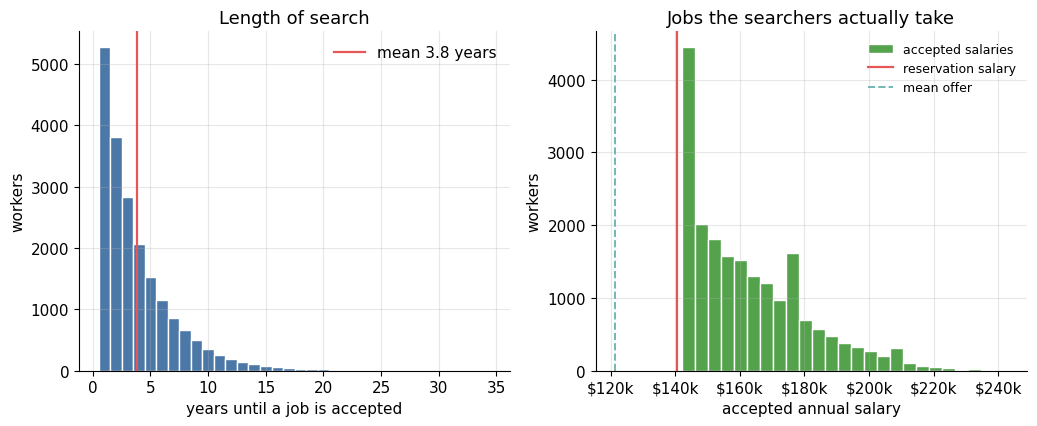

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

years = rejections + 1
bins = np.arange(0.5, years.max() + 1.5, 1)
axes[0].hist(years, bins=bins, color="#4C78A8", edgecolor="white")
axes[0].axvline(expected_years, color="#E45756", lw=1.6, label=f"mean {expected_years:.1f} years")
axes[0].set_xlabel("years until a job is accepted")
axes[0].set_ylabel("workers")
axes[0].set_title("Length of search")
axes[0].legend(frameon=False)

axes[1].hist(accepted_wage, bins=25, color="#54A24B", edgecolor="white", label="accepted salaries")
axes[1].axvline(reservation, color="#E45756", lw=1.6, label="reservation salary")
axes[1].axvline(mean_offer, color="#72B7B2", lw=1.4, ls="--", label="mean offer")
axes[1].set_xlabel("accepted annual salary")
axes[1].set_ylabel("workers")
axes[1].set_title("Jobs the searchers actually take")
dollar_axis(axes[1])
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()


## 7. Reading the example

The numbers below are computed by the cells above. The economic points are:

1. **Offers span \$70,000 to \$250,000, but the typical offer is much closer to the bottom.** The beta-binomial piles probability on lower salaries. The mean offer is well below the midpoint of the grid (\$160,000).

2. **The reservation salary sits above the mean offer.** The worker turns down most draws, including many that pay more than the \$30,000 received while unemployed. Those offers lose because the alternative is a permanent raise, not just a better year.

3. **Accepted jobs are a selected sample.** The mean accepted salary is higher than the mean offer. That gap is the return to search.

4. **Patience and benefits both raise the reservation salary.** A higher \(\beta\) makes the future raise more valuable. A higher \(c\) makes the wait cheaper, so unemployment lasts longer.

5. **The lifetime value of a job is \(w/(1-\beta)\), not \(w\).** At \(\beta=0.95\), a \$70,000 contract is worth \$1.4 million in present value and a \$250,000 contract is worth \$5 million. The reservation rule compares those lifetime values with the value of continuing to search.
